In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
import numpy as np


In [ ]:
#Define the model achitecture
model = Sequential()
model.add(Dense(512, input_shape=(784,),activation='relu'))
model.add(Dropout(0.2))
#model.add(Dense(512,activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))

#Softmax => logistic --> (out)/sum(output) -> Probabilities. --> 0 -->1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
path="/content/drive/My Drive/data/digit.csv"
df =pd.read_csv(path)
data=pd.read_csv(path,header=None)

Mounted at /content/drive


In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
X=data.values

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test, Y_train, Y_test=train_test_split(X[:,:-1],X[:,-1],test_size=0.2)

In [ ]:
Y_train

array([7, 8, 3, 6, 6, 2, 6, 8, 9, 3, 2, 0, 6, 5, 5, 4, 9, 8, 4, 3, 1, 9,
       9, 1, 4, 2, 9, 1, 0, 0, 9, 4, 6, 6, 6, 5, 7, 3, 4, 1, 0, 3, 1, 6,
       7, 2, 1, 5, 0, 6, 5, 7, 0, 3, 7, 8, 6, 7, 4, 2, 5, 9, 3, 7, 8, 2,
       8, 5, 6, 3, 3, 4, 6, 1, 2, 5, 8, 3, 2, 4, 5, 9, 5, 7, 2, 2, 6, 0,
       8, 8, 4, 1, 1, 9, 0, 4, 4, 7, 0, 2, 4, 8, 1, 3, 0, 7, 3, 5, 2, 0,
       3, 9, 0, 4, 9, 5, 5, 9, 1, 7, 6, 0, 3, 5, 7, 2, 6, 6, 9, 6, 8, 5,
       7, 1, 8, 6, 7, 4, 7, 0, 4, 4, 6, 0, 1, 2, 8, 0, 0, 1, 6, 3, 5, 0,
       4, 5, 9, 6, 9, 0, 1, 5, 8, 4, 0, 5, 4, 9, 0, 3, 7, 3, 4, 8, 9, 3,
       7, 9, 1, 1, 8, 5, 5, 1, 6, 6, 5, 2, 7, 9, 5, 1, 2, 0, 1, 4, 7, 2,
       1, 4, 2, 4, 4, 9, 5, 2, 7, 1, 8, 3, 6, 3, 1, 5, 2, 7, 1, 8, 3, 9,
       8, 3, 3, 6, 4, 3, 1, 8, 9, 6, 2, 8, 3, 8, 9, 5, 8, 1, 6, 2, 4, 2,
       3, 9, 1, 7, 1, 8, 9, 5, 3, 8, 0, 4, 4, 5, 2, 8, 4, 3, 6, 0, 6, 4,
       5, 2, 7, 2, 2, 3, 6, 7, 3, 0, 8, 9, 1, 4, 3, 5, 6, 7, 3, 9, 1, 3,
       4, 6, 9, 5, 7, 3, 8, 8, 2, 6, 8, 4, 7, 1, 9,

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
#Make the model learn
#MORE OPTIMIZER DETAILS here https://keras.io/optimizers/

In [ ]:
from keras.utils import to_categorical
y_train = keras.utils.to_categorical(Y_train, num_classes=10)
y_test = keras.utils.to_categorical(Y_test, num_classes=10)


In [ ]:
print(y_train)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [ ]:
print(y_test)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0.

In [ ]:
history=model.fit(X_train, y_train, epochs=200, verbose=1,validation_data=(X_test, y_test))


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3238 - loss: 84.1813 - val_accuracy: 0.7700 - val_loss: 19.4243
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8076 - loss: 13.5340 - val_accuracy: 0.8200 - val_loss: 16.2087
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9087 - loss: 5.5135 - val_accuracy: 0.8500 - val_loss: 15.8240
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9466 - loss: 3.5986 - val_accuracy: 0.8700 - val_loss: 14.4531
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9688 - loss: 0.9675 - val_accuracy: 0.8500 - val_loss: 15.9344
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9560 - loss: 1.2904 - val_accuracy: 0.8900 - val_loss: 14.2529
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9814 - loss: 0.9230 - val_accuracy: 0.8800 - val_loss: 12.7833
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9956 - loss: 0.0556 - val_acc

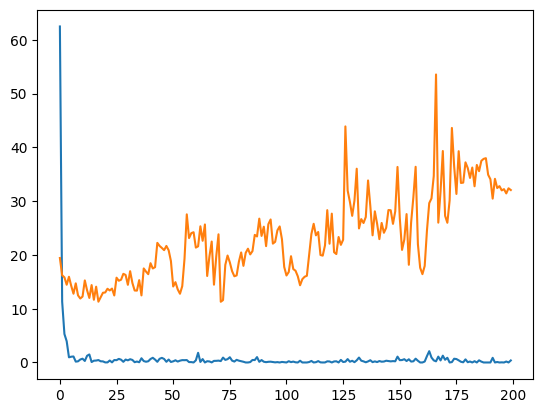

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

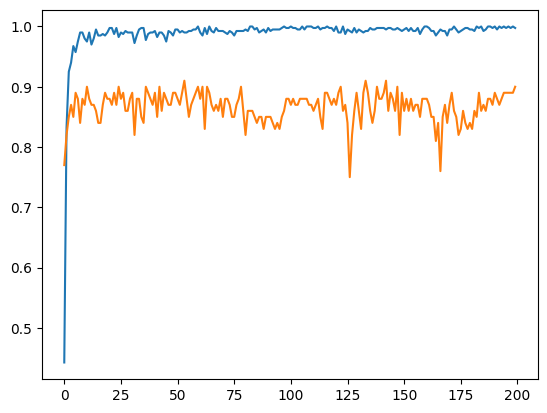

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])


In [ ]:
X_tests=X_test/255
X_trains=X_train/255

In [ ]:
history=model.fit(X_trains, y_train, epochs=200, verbose=1,validation_data=(X_tests, y_test))


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.2572 - val_accuracy: 0.8700 - val_loss: 0.4215
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9987 - loss: 0.0529 - val_accuracy: 0.8800 - val_loss: 0.4258
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0262 - val_accuracy: 0.8900 - val_loss: 0.4170
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0218 - val_accuracy: 0.8900 - val_loss: 0.4233
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.8800 - val_loss: 0.4444
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.8800 - val_loss: 0.4533
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.8800 - val_loss: 0.4504
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.

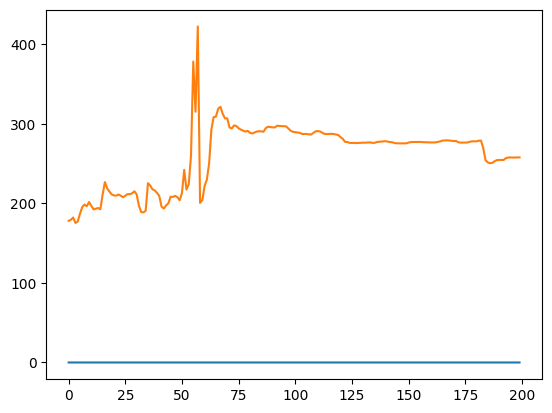

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_train)
Y_pred = np.argmax(y_pred, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_train, Y_pred))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_train, Y_pred, target_names=target_names))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Confusion Matrix
[[34  0  0  0  0  0  0  0  0  0]
 [ 0 39  0  0  0  0  0  0  0  0]
 [ 0  0 42  0  0  0  0  0  0  0]
 [ 0  0  0 41  0  0  0  0  0  0]
 [ 0  0  0  0 44  0  0  0  0  0]
 [ 0  0  0  0  0 42  0  0  0  0]
 [ 0  0  0  0  0  0 40  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 41  0]
 [ 0  0  0  0  0  0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        42
           3       1.00      1.00      1.00        41
           4       1.00      1.00      1.00        44
           5       1.00      1.00      1.00        42
           6       1.00      1.00      1.00        40
           7       1.00      1.00      1.00        36
           8       1.00      1.00      1.00        41
           9       1.00      1.00      1.00       

In [ ]:

y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Confusion Matrix
[[15  0  0  0  0  0  0  0  0  1]
 [ 0  9  1  0  0  0  0  0  0  1]
 [ 0  0  5  0  0  0  0  3  0  0]
 [ 0  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 0  0  0  1  0  7  0  0  0  0]
 [ 0  0  0  0  1  0  9  0  0  0]
 [ 0  0  0  1  0  0  0 11  0  2]
 [ 0  1  0  0  0  0  0  0  7  1]
 [ 0  0  0  0  0  0  0  0  0  9]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.90      0.82      0.86        11
           2       0.83      0.62      0.71         8
           3       0.82      1.00      0.90         9
           4       0.86      1.00      0.92         6
           5       1.00      0.88      0.93         8
           6       1.00      0.90      0.95        10
           7       0.79      0.79      0.79        14
           8       1.00      0.78      0.88         9
           9       0.64      1.00      0.78        

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

# I. Add layers

In [ ]:
model = Sequential()
model.add(Dense(512, input_shape=(784,), activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(512,activation="relu"))
model.add(Dense(10,activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(X_trains, y_train, epochs=200, verbose=1,validation_data=(X_tests, y_test))

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4275 - loss: 1.8775 - val_accuracy: 0.8000 - val_loss: 0.7951
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8569 - loss: 0.5372 - val_accuracy: 0.8600 - val_loss: 0.5827
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9077 - loss: 0.2979 - val_accuracy: 0.8700 - val_loss: 0.4513
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9387 - loss: 0.1707 - val_accuracy: 0.8800 - val_loss: 0.4769
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9824 - loss: 0.0934 - val_accuracy: 0.8600 - val_loss: 0.5137
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9793 - loss: 0.0721 - val_accuracy: 0.8700 - val_loss: 0.4795
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9968 - loss: 0.0357 - val_accuracy: 0.8900 - val_loss: 0.4979
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0259 - val_accuracy: 0.

In [ ]:
y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Confusion Matrix
[[16  0  0  0  0  0  0  0  0  0]
 [ 0  9  0  0  0  0  1  0  0  1]
 [ 0  0  5  0  0  0  0  3  0  0]
 [ 0  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  5  0  0  0  0  1]
 [ 0  0  0  1  0  7  0  0  0  0]
 [ 0  1  0  0  1  0  8  0  0  0]
 [ 0  0  0  1  0  0  0 11  0  2]
 [ 0  0  0  0  0  0  0  0  8  1]
 [ 0  0  0  0  0  0  0  0  0  9]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.90      0.82      0.86        11
           2       1.00      0.62      0.77         8
           3       0.82      1.00      0.90         9
           4       0.83      0.83      0.83         6
           5       1.00      0.88      0.93         8
           6       0.89      0.80      0.84        10
           7       0.79      0.79      0.79        14
           8       1.00      0.89      0.94         9
           9       0.64      1.00      0.78        

accuracy while trainng reach one faster but testing accuray is worse -> sign of overfitting

# II. Add Dropout

In [ ]:
model = Sequential()
model.add(Dense(512, input_shape=(784,), activation="relu"))
model.add(Dropout(0.2))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax')) # output layer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, verbose=1, epochs=200, validation_data=(X_tests, y_test))

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2825 - loss: 110.2844 - val_accuracy: 0.6700 - val_loss: 1.5890
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7881 - loss: 21.0202 - val_accuracy: 0.8000 - val_loss: 1.4642
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8685 - loss: 9.4546 - val_accuracy: 0.8000 - val_loss: 1.3710
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9027 - loss: 6.1030 - val_accuracy: 0.8100 - val_loss: 1.3738
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9124 - loss: 3.5798 - val_accuracy: 0.8400 - val_loss: 1.3769
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9601 - loss: 1.9164 - val_accuracy: 0.8700 - val_loss: 1.3818
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9795 - loss: 0.5186 - val_accuracy: 0.8400 - val_loss: 1.3801
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9682 - loss: 2.0036 - val_accuracy:

In [137]:
y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Confusion Matrix
[[15  0  0  0  0  0  0  0  1  0]
 [ 0  9  1  0  0  0  0  0  1  0]
 [ 0  0  5  0  0  0  0  3  0  0]
 [ 0  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 0  0  0  1  0  6  0  0  1  0]
 [ 0  0  0  0  1  0  9  0  0  0]
 [ 0  0  0  1  1  0  0 11  0  1]
 [ 0  0  0  0  0  0  0  0  9  0]
 [ 0  0  0  0  0  0  0  0  0  9]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       1.00      0.82      0.90        11
           2       0.83      0.62      0.71         8
           3       0.82      1.00      0.90         9
           4       0.75      1.00      0.86         6
           5       1.00      0.75      0.86         8
           6       1.00      0.90      0.95        10
           7       0.79      0.79      0.79        14
           8       0.75      1.00      0.86         9
           9       0.90      1.00      0.95        

 # III. Add Normalization Layer

In [133]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential()
model.add(Dense(512, input_shape=(784,), activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax')) # output layer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,098 (1.56 MB)

 Trainable params: 408,074 (1.56 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [136]:
model.fit(X_trains, y_train, epochs=200, verbose=1, validation_data=[X_tests, y_test])

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9762 - loss: 0.0946 - val_accuracy: 0.8100 - val_loss: 1.0116
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9946 - loss: 0.0441 - val_accuracy: 0.8400 - val_loss: 0.9064
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9946 - loss: 0.0407 - val_accuracy: 0.8500 - val_loss: 0.8298
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.0179 - val_accuracy: 0.8600 - val_loss: 0.7592
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.8700 - val_loss: 0.7077
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.8700 - val_loss: 0.6629
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8700 - val_loss: 0.6197
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.

In [138]:
y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Confusion Matrix
[[15  0  0  0  0  0  0  0  1  0]
 [ 0  9  1  0  0  0  0  0  1  0]
 [ 0  0  5  0  0  0  0  3  0  0]
 [ 0  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 0  0  0  1  0  6  0  0  1  0]
 [ 0  0  0  0  1  0  9  0  0  0]
 [ 0  0  0  1  1  0  0 11  0  1]
 [ 0  0  0  0  0  0  0  0  9  0]
 [ 0  0  0  0  0  0  0  0  0  9]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       1.00      0.82      0.90        11
           2       0.83      0.62      0.71         8
           3       0.82      1.00      0.90         9
           4       0.75      1.00      0.86         6
           5       1.00      0.75      0.86         8
           6       1.00      0.90      0.95        10
           7       0.79      0.79      0.79        14
           8       0.75      1.00      0.86         9
           9       0.90      1.00      0.95        

# IV. Add Early Stopping & Callback

In [ ]:

# Define callbacks example
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
history = model.fit(X_trains, y_train, verbose=1,epochs=200, validation_data=[X_tests, y_test], callbacks=early_stopping)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 1.0000 - loss: 1.6992e-04 - val_accuracy: 0.8800 - val_loss: 0.6589
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 2.4781e-04 - val_accuracy: 0.8700 - val_loss: 0.6141
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 1.5953e-04 - val_accuracy: 0.8800 - val_loss: 0.7192
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 1.0867e-04 - val_accuracy: 0.8800 - val_loss: 0.7029
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 1.0171e-04 - val_accuracy: 0.8800 - val_loss: 0.7222
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 1.3715e-04 - val_accuracy: 0.8900 - val_loss: 0.7493
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 2.2251e-04 - val_accuracy: 0.8800 - val_loss: 0.7155
Epoch 7: early stopping
Restoring model weights from the end of the best epo

In [ ]:
y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

# V. Add Checkpoint

In [ ]:
callbacks = ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)

In [140]:
history = model.fit(X_trains, y_train, verbose=1,epochs=200, validation_data=[X_test, y_test], callbacks=callbacks)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 3.6234e-05

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 1.0000 - loss: 3.6833e-05 - val_accuracy: 0.8800 - val_loss: 111.1198
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 4.5932e-05 - val_accuracy: 0.8800 - val_loss: 111.1258
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 4.5346e-05 - val_accuracy: 0.8800 - val_loss: 111.3701
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 6.7636e-05 - val_accuracy: 0.8800 - val_loss: 111.7589
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 5.8201e-05 - val_accuracy: 0.8800 - val_loss: 112.2823
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 5.5648e-05 - val_accuracy: 0.8800 - val_loss: 112.8644
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 4.8104e-05 - val_accuracy: 0.8800 - val_loss: 113.2502
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - l

In [141]:
y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Confusion Matrix
[[16  0  0  0  0  0  0  0  0  0]
 [ 0  9  1  0  0  0  0  0  1  0]
 [ 0  0  5  0  0  0  0  3  0  0]
 [ 0  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 0  0  0  1  0  6  0  0  1  0]
 [ 0  0  0  0  1  0  9  0  0  0]
 [ 0  0  0  1  1  0  0 11  0  1]
 [ 0  0  0  0  0  0  0  0  9  0]
 [ 0  0  0  0  0  0  0  1  1  7]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.82      0.90        11
           2       0.83      0.62      0.71         8
           3       0.82      1.00      0.90         9
           4       0.75      1.00      0.86         6
           5       1.00      0.75      0.86         8
           6       1.00      0.90      0.95        10
           7       0.73      0.79      0.76        14
           8       0.75      1.00      0.86         9
           9       0.88      0.78      0.82        

SUMMARISE.....

- Complicated can lead to overfitting and longer training time
- having dropout layer can reduce runtime and prevent weight from chaning rapidly
- Normalized data to same range to make same learning rate affect all the weight similarly
- early stopping can reduce the run time stop training early if already satisfy with the model
- Check point can save the best model from all the epochs